In [1]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time
import socolors

from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict

from latcom.utils.optical_loading import pwv_interp

%load_ext autoreload
%autoreload 2

In [2]:
with open("../../nets/nets_07162026.pk", "rb") as f:
    net_dict = pk.load(f)


c_base = "C0"
c_goal = "C3"

In [3]:
# df_yield = yd.parse_yield(net_dict=net_dict)
df_yield = parse_dict(net_dict=net_dict)
toby_df = yd.aso_toby_df
pton_df = yd.ptown_df

In [4]:
t_cut_low = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-08-01T00:00:00", format="isot", scale="utc")

t_cut_low_nominal = Time("2025-10-01T00:00:00", format="isot", scale="utc")
t_cut_high_nominal = Time("2025-11-16T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df_yield.labels)
weighted_means = np.zeros(len(set_labels))
aso_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 3)
        & (df_yield.t_obs < t_cut_high_nominal.unix)
        & (t_cut_low_nominal.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    weighted_means[i] = np.mean(data)

    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 3)
        & (df_yield.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    aso_means[i] = np.mean(data)
means_df_nominal = pd.DataFrame({"labels": set_labels, "yields": weighted_means, "aso_yields":aso_means})

In [5]:
t_cut_low = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2026-08-01T00:00:00", format="isot", scale="utc")

set_labels = np.unique(df_yield.labels)
weighted_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = df_yield.where(
        (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 1 / np.sin(np.deg2rad(50)))
        & (df_yield.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < df_yield.t_obs)
        & (df_yield.labels == label)
    ).yields
    weighted_means[i] = np.mean(data)
means_df = pd.DataFrame({"labels": set_labels, "yields": weighted_means})

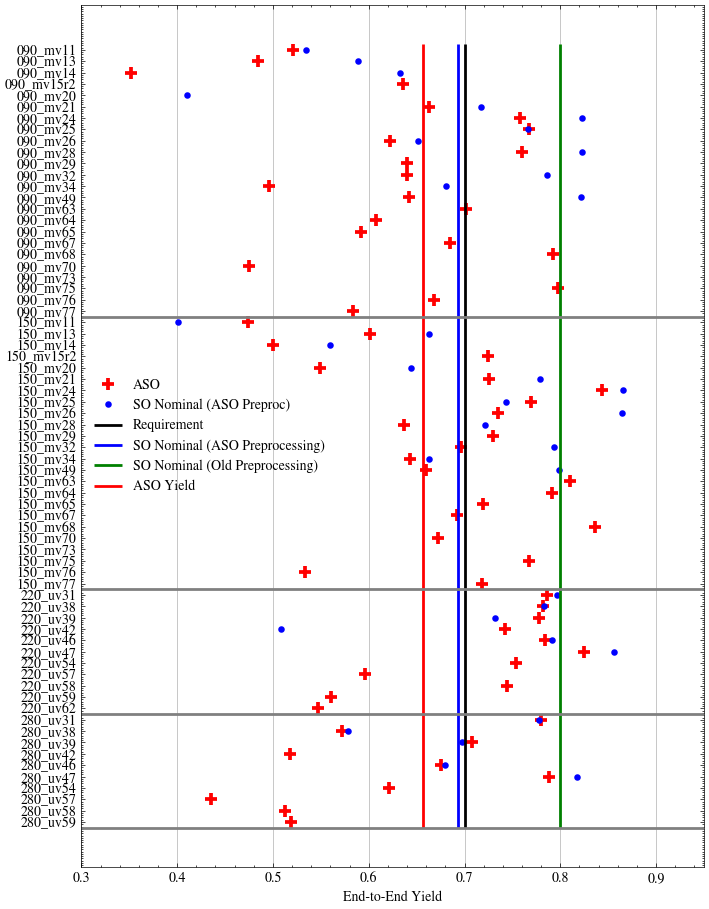

In [6]:
plt.style.use("apj-fullwidth")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 9))


sns.pointplot(data=means_df, x="yields", y="labels", label="ASO", marker="+", linestyle="none", color="red",)
sns.pointplot(data=means_df_nominal, x="yields", y="labels", label="SO Nominal (ASO Preproc)", marker="o", linestyle="none", color="blue", markersize=2)
"""
sns.pointplot(data=toby_df, x="yields", y="labels", linestyle="none", marker="x", color="orange", zorder=2, label="On-site Readout",)

sns.pointplot(data=ptown_df, x="yields", y="labels", linestyle="none", marker="+", color="0.05", zorder=2, label="PTown Dark",)
"""

df_melted = means_df_nominal.melt(id_vars='labels', value_vars=['yields', 'aso_yields'], 
                    var_name='Time', value_name='Yield')
grouped = df_melted.groupby('labels')
for name, group in grouped:
    # Get the Before (x=0) and After (x=1) values
    before_val = group.loc[group['Time'] == 'yields', 'Yield'].values[0]
    after_val = group.loc[group['Time'] == 'aso_yields', 'Yield'].values[0]
    # Coordinates for annotate: (x_start, y_start), (x_end, y_end)
    ax.annotate("", xy=(1, after_val), xytext=(0, before_val),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5, mutation_scale=15),
                zorder=10)


plt.xlim(0.3, 0.95)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color="black")
plt.vlines(np.nanmean(means_df_nominal.yields.to_numpy()), ymin=ymin, ymax=ymax, label="SO Nominal (ASO Preprocessing)", color="blue")
plt.vlines(0.80, ymin=ymin, ymax=ymax, label="SO Nominal (Old Preprocessing)", color="green")

# plt.vlines(np.nanmean(df_yield.where(df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) <= 1 / np.sin(np.deg2rad(50))).yields),
#    ymin=ymin, ymax=ymax, label="On-Sky Average", color="black",
# )
plt.vlines(np.nanmean(means_df.yields), ymin=ymin, ymax=ymax, label="ASO Yield", color="red",)
#plt.vlines(np.nanmean(toby_df.yields), ymin=ymin, ymax=ymax, label="On-site Readout Average", color="orange",)


pos_090 = (len([label for label in set(df_yield.labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df_yield.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df_yield.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df_yield.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220, pos_280], xmin=xmin, xmax=xmax, color="0.5")

plt.legend()

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")

plt.savefig("../../plts/aso_vs_nominal_yield.png", dpi=600, bbox_inches="tight")
plt.savefig("../../plts/aso_vs_nominal_yield.pdf", dpi=600, bbox_inches="tight")

# Daily yields

In [107]:
import astropy.units as u
import matplotlib.dates as mdates
from pathlib import Path
import datetime as dt

pwv = pwv_interp()

t0 = Time("2026-04-26T00:00:00", format="isot", scale="utc")
tf = Time("2026-07-04T00:00:00", format="isot", scale="utc")
ndays = int(((tf-t0)/u.day).value)
days = np.linspace(t0, tf, ndays)

In [103]:
daily_yields = {label:np.zeros(len(days)) for label in set_labels}
daily_yields["total_yield"] = np.zeros(len(days))
daily_yields["pwv"] = np.zeros(len(days))

for i, day in enumerate(days):
    cur_yields = np.zeros(len(set_labels))
    for j, label in enumerate(set_labels):
        data = df_yield.where(
            (df_yield.pwv / np.sin(np.deg2rad(df_yield.el)) < 1 / np.sin(np.deg2rad(50)))
            & (df_yield.t_obs < (day + 1*u.day).unix)
            & (day.unix < df_yield.t_obs)
            & (df_yield.labels == label)
        ).yields
        mean_data = np.nanmean(data)
        cur_yields[j] = mean_data
        daily_yields[label][i] = mean_data
    hours = np.linspace(day, day + 1*u.day, 24)
    pwvs = np.zeros(len(hours))
    for j, hour in enumerate(hours):
        pwvs[j] = pwv(hour.unix)
    daily_yields["pwv"][i] = np.nanmean(pwvs)
    daily_yields["total_yield"][i] = np.nanmean(cur_yields)

/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:14: RuntimeWarning: Mean of empty slice
  mean_data = np.nanmean(data)
/tmp/ipykernel_190467/1804120990.py:1

In [108]:
times = [dt.datetime.fromtimestamp(day.unix) for day in days]

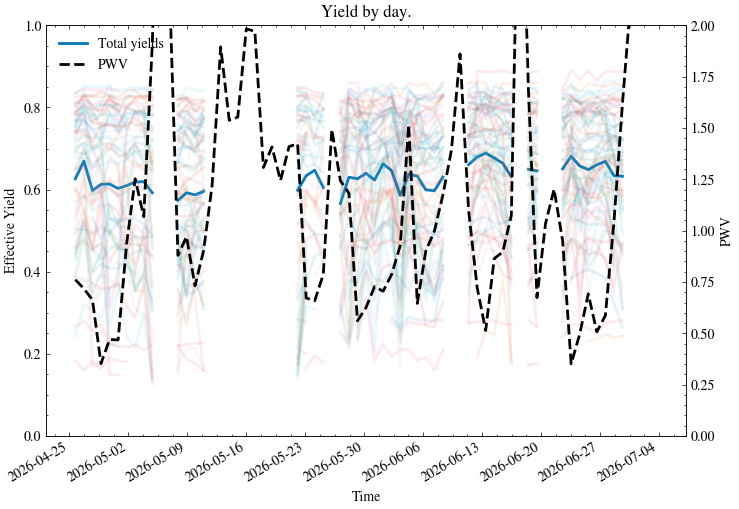

In [114]:
fig, ax = plt.subplots()
lns = []

total = ax.plot(times, daily_yields["total_yield"], label="Total yields")
for key in daily_yields:
    if key == "total_yields" or key == "pwv": continue
    ax.plot(times, daily_yields[key], label=key, alpha = 0.1)

ax2 = ax.twinx()
pw = ax2.plot(times, daily_yields["pwv"], label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Effective Yield")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gcf().autofmt_xdate()

lns = lns + total + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield by day.")
output_dir = Path(f"../../plts/yields/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"daily_yields.pdf", dpi=600)
plt.savefig(output_dir / f"daily_yields.png", dpi=600)

plt.show()

# ISO Yields

In [14]:
with open("../../nets/nets_12052025.pk", "rb") as f:
    iso_dict = pk.load(f)

with open("../../nets/nets_07162026.pk", "rb") as f:
    aso_dict = pk.load(f)

c_base = "C0"
c_goal = "C3"
iso_df = parse_dict(net_dict=iso_dict)
aso_df = parse_dict(net_dict=aso_dict)

In [41]:
t_cut_low = Time("2025-10-01T00:00:00", format="isot", scale="utc")
t_cut_high = Time("2025-10-20T00:00:00", format="isot", scale="utc")

t_cut_low_aso = Time("2026-06-01T00:00:00", format="isot", scale="utc")
t_cut_high_aso = Time("2026-08-01T00:00:00", format="isot", scale="utc")

set_labels = np.unique(aso_df.labels)
iso_means = np.zeros(len(set_labels))
aso_proc_means = np.zeros(len(set_labels))
aso_means = np.zeros(len(set_labels))
for i, label in enumerate(set_labels):
    data = iso_df.where(
        (iso_df.pwv / np.sin(np.deg2rad(iso_df.el)) < 3)
        & (iso_df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < iso_df.t_obs)
        & (iso_df.labels == label)
    ).yields
    iso_means[i] = np.mean(data)

    data = aso_df.where(
        (aso_df.pwv / np.sin(np.deg2rad(aso_df.el)) < 3)
        & (aso_df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < aso_df.t_obs)
        & (aso_df.labels == label)
    ).yields
    aso_proc_means[i] = np.mean(data)

    data = aso_df.where(
        (aso_df.pwv / np.sin(np.deg2rad(aso_df.el)) < 3)
        & (aso_df.t_obs < t_cut_high_aso.unix)
        & (t_cut_low_aso.unix < aso_df.t_obs)
        & (aso_df.labels == label)
    ).yields
    aso_means[i] = np.mean(data)
means_df_iso = pd.DataFrame({"labels": set_labels, "iso_yields": iso_means, "aso_proc_yields":aso_proc_means, "aso_yields":aso_means})

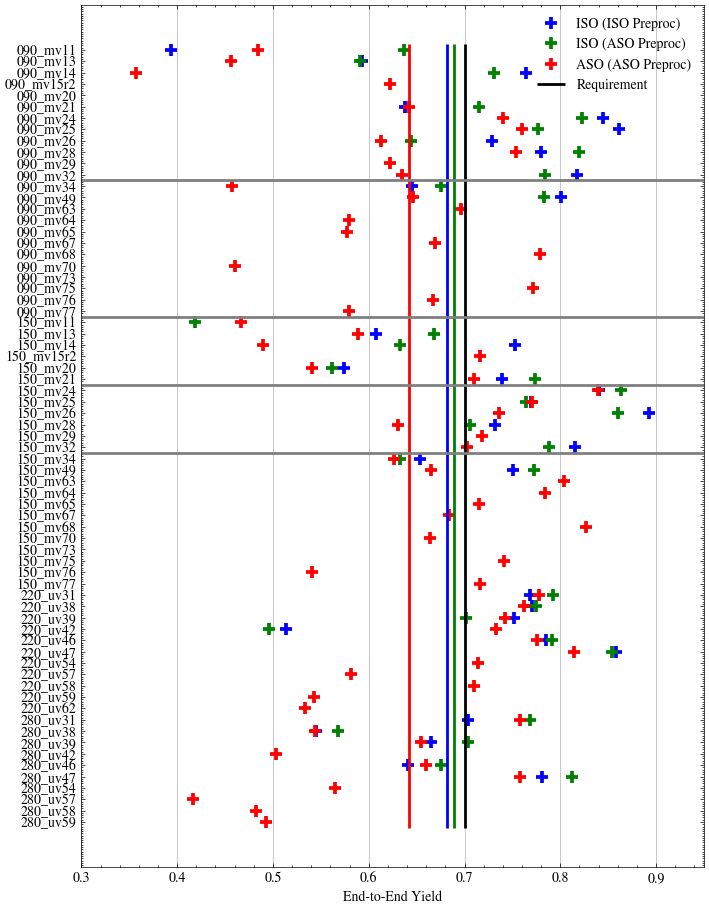

In [42]:
plt.style.use("apj-fullwidth")

# Initialize the figure with a logarithmic x axis
f, ax = plt.subplots(figsize=(7, 9))


sns.pointplot(data=means_df_iso, x="iso_yields", y="labels", label="ISO (ISO Preproc)", marker="+", linestyle="none", color="blue",)
sns.pointplot(data=means_df_iso, x="aso_proc_yields", y="labels", label="ISO (ASO Preproc)", marker="+", linestyle="none", color="green",)
sns.pointplot(data=means_df_iso, x="aso_yields", y="labels", label="ASO (ASO Preproc)", marker="+", linestyle="none", color="red",)


plt.xlim(0.3, 0.95)

ymax, ymin = ax.get_ylim()
xmax, xmin = ax.get_xlim()

plt.vlines(0.7, ymin=ymin, ymax=ymax, label="Requirement", color="black")
plt.vlines(np.nanmean(means_df_iso.iso_yields.to_numpy()), ymin=ymin, ymax=ymax, color="blue")
plt.vlines(np.nanmean(means_df_iso.aso_proc_yields.to_numpy()), ymin=ymin, ymax=ymax, color="green")
plt.vlines(np.nanmean(means_df_iso.aso_yields.to_numpy()), ymin=ymin, ymax=ymax, color="red")


pos_090 = (len([label for label in set(df_yield.labels.to_numpy()) if "090" in label]) - 0.5)
pos_150 = pos_090 + len([label for label in set(df_yield.labels.to_numpy()) if "150" in label])
pos_220 = pos_150 + len([label for label in set(df_yield.labels.to_numpy()) if "220" in label])
pos_280 = pos_220 + len([label for label in set(df_yield.labels.to_numpy()) if "280" in label])

plt.hlines([pos_090, pos_150, pos_220, pos_280], xmin=xmin, xmax=xmax, color="0.5")

plt.legend()

ax.xaxis.grid(True)
ax.set(xlabel="End-to-End Yield", ylabel="")

plt.savefig("../../plts/iso_yield.png", dpi=600, bbox_inches="tight")
plt.savefig("../../plts/iso_yield.pdf", dpi=600, bbox_inches="tight")

In [26]:
for i, label in enumerate(set_labels):
    data_iso = iso_df.loc[(
        (iso_df.pwv / np.sin(np.deg2rad(iso_df.el)) < 3)
        & (iso_df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < iso_df.t_obs)
        & (iso_df.labels == label)
    )]

    data_aso = aso_df.loc[(
        (aso_df.pwv / np.sin(np.deg2rad(aso_df.el)) < 3)
        & (aso_df.t_obs < t_cut_high.unix)
        & (t_cut_low.unix < aso_df.t_obs)
        & (aso_df.labels == label)
    )]
    print(f"ISO obs: {len(data_iso)}, ASO obs: {len(data_aso)}")

ISO obs: 280, ASO obs: 314
ISO obs: 285, ASO obs: 313
ISO obs: 134, ASO obs: 149
ISO obs: 279, ASO obs: 313
ISO obs: 259, ASO obs: 284
ISO obs: 283, ASO obs: 309
ISO obs: 283, ASO obs: 312
ISO obs: 274, ASO obs: 308
ISO obs: 284, ASO obs: 311
ISO obs: 288, ASO obs: 315
ISO obs: 274, ASO obs: 312
ISO obs: 289, ASO obs: 316
ISO obs: 281, ASO obs: 315
ISO obs: 286, ASO obs: 313
ISO obs: 130, ASO obs: 131
ISO obs: 287, ASO obs: 316
ISO obs: 260, ASO obs: 286
ISO obs: 287, ASO obs: 312
ISO obs: 284, ASO obs: 313
ISO obs: 279, ASO obs: 309
ISO obs: 290, ASO obs: 313
ISO obs: 289, ASO obs: 314
ISO obs: 287, ASO obs: 315
ISO obs: 290, ASO obs: 314
ISO obs: 236, ASO obs: 289
ISO obs: 255, ASO obs: 310
ISO obs: 243, ASO obs: 293
ISO obs: 257, ASO obs: 311
ISO obs: 259, ASO obs: 314
ISO obs: 216, ASO obs: 256
ISO obs: 235, ASO obs: 286
ISO obs: 247, ASO obs: 291
ISO obs: 242, ASO obs: 274
ISO obs: 240, ASO obs: 289
ISO obs: 261, ASO obs: 312
ISO obs: 215, ASO obs: 256


In [39]:
np.nanmean(means_df_iso.iso_yields.to_numpy())

np.float64(0.6821855765923023)

In [40]:
np.nanmean(means_df_iso.aso_yields.to_numpy())

np.float64(0.6405060316112465)